In [1]:
!pip install ultralytics opencv-python pandas pycocotools -q

In [3]:
import os

# Вариант А: если работаете прямо в Kaggle Notebook — датасет уже примонтирован,
# просто укажите путь ниже (обычно /kaggle/input/mocs-dataset/).
# Вариант Б: если работаете локально в Jupyter — скачиваем через kagglehub.

RUNNING_ON_KAGGLE = os.path.exists("/kaggle/input")

if RUNNING_ON_KAGGLE:
    DATASET_ROOT = "/kaggle/input/mocs-dataset"
else:
    import kagglehub
    DATASET_ROOT = kagglehub.dataset_download("xiaopan9802/mocs-dataset")

print("Путь к датасету:", DATASET_ROOT)

# Разведка структуры - смотрим, что реально внутри, до 3 уровней вложенности
for root, dirs, files in os.walk(DATASET_ROOT):
    depth = root[len(DATASET_ROOT):].count(os.sep)
    if depth > 2:
        continue
    indent = "  " * depth
    print(f"{indent}{os.path.basename(root) or root}/")
    for f in files[:5]:
        print(f"{indent}  {f}")
    if len(files) > 5:
        print(f"{indent}  ... и ещё {len(files) - 5} файлов")

C:\Users\edwar\miniconda3\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Путь к датасету: C:\Users\edwar\.cache\kagglehub\datasets\xiaopan9802\mocs-dataset\versions\1
1/
  instances_train.json
  instances_val.json
  instances_train/
    Readme.txt
    instances_train/
      0000001.jpg
      0000002.jpg
      0000003.jpg
      0000004.jpg
      0000005.jpg
      ... и ещё 19399 файлов
  instances_val/
    Readme.txt
    instances_val/
      0019406.jpg
      0019407.jpg
      0019408.jpg
      0019409.jpg
      0019410.jpg
      ... и ещё 3995 файлов


In [4]:
# 13 категорий согласно официальному описанию MOCS.
# Индексы должны соответствовать тем, что реально в annotation-файлах датасета -
# после разведки структуры (ячейка 2) при необходимости сверим/поправим порядок.
MOCS_CLASSES = [
    "worker",
    "tower_crane",
    "hanging_hook",
    "vehicle_crane",
    "roller",
    "bulldozer",
    "excavator",
    "truck",
    "loader",
    "pump_truck",
    "concrete_mixer",
    "pile_driver",
    "other_vehicle",
]
print("Классы MOCS:", MOCS_CLASSES)

Классы MOCS: ['worker', 'tower_crane', 'hanging_hook', 'vehicle_crane', 'roller', 'bulldozer', 'excavator', 'truck', 'loader', 'pump_truck', 'concrete_mixer', 'pile_driver', 'other_vehicle']


In [5]:
import json
import glob
import shutil
from pathlib import Path
import xml.etree.ElementTree as ET

YOLO_DATASET_DIR = Path("mocs_yolo")
YOLO_DATASET_DIR.mkdir(exist_ok=True)

def detect_annotation_format(dataset_root):
    """Проверяем, что за формат разметки лежит в датасете."""
    json_files = glob.glob(f"{dataset_root}/**/*.json", recursive=True)
    xml_files = glob.glob(f"{dataset_root}/**/*.xml", recursive=True)
    if json_files:
        return "coco", json_files
    elif xml_files:
        return "voc", xml_files
    else:
        raise RuntimeError(
            "Не нашёл ни .json (COCO), ни .xml (VOC) файлов разметки. "
            "Проверьте вывод ячейки 2 и уточните путь вручную."
        )

ann_format, ann_files = detect_annotation_format(DATASET_ROOT)
print("Обнаружен формат разметки:", ann_format)
print("Найдено файлов разметки:", len(ann_files))
print("Пример:", ann_files[:3])

Обнаружен формат разметки: coco
Найдено файлов разметки: 2
Пример: ['C:\\Users\\edwar\\.cache\\kagglehub\\datasets\\xiaopan9802\\mocs-dataset\\versions\\1\\instances_train.json', 'C:\\Users\\edwar\\.cache\\kagglehub\\datasets\\xiaopan9802\\mocs-dataset\\versions\\1\\instances_val.json']


In [9]:
def convert_coco_to_yolo(coco_json_path, images_dir, out_labels_dir, out_images_dir):
    """Конвертирует один COCO-json файл в YOLO-разметку (по одному .txt на картинку)."""
    out_labels_dir = Path(out_labels_dir)
    out_images_dir = Path(out_images_dir)
    out_labels_dir.mkdir(parents=True, exist_ok=True)
    out_images_dir.mkdir(parents=True, exist_ok=True)

    with open(coco_json_path, "r", encoding="utf-8") as f:
        coco = json.load(f)

    # category_id (как в json) -> порядковый индекс класса для YOLO
    categories = sorted(coco["categories"], key=lambda c: c["id"])
    cat_id_to_idx = {c["id"]: i for i, c in enumerate(categories)}
    class_names = [c["name"] for c in categories]

    images_by_id = {img["id"]: img for img in coco["images"]}
    anns_by_image = {}
    for ann in coco["annotations"]:
        anns_by_image.setdefault(ann["image_id"], []).append(ann)

    n_converted = 0
    for image_id, img_info in images_by_id.items():
        file_name = img_info["file_name"]
        width, height = img_info["width"], img_info["height"]

        src_path = Path(images_dir) / file_name
        if not src_path.exists():
            # изображение могло лежать во вложенной папке - пробуем найти по имени
            matches = list(Path(images_dir).rglob(Path(file_name).name))
            if not matches:
                continue
            src_path = matches[0]

        dst_path = out_images_dir / Path(file_name).name
        if not dst_path.exists():
            shutil.copy(src_path, dst_path)

        label_lines = []
        for ann in anns_by_image.get(image_id, []):
            x, y, w, h = ann["bbox"]  # COCO bbox: [x_min, y_min, width, height]
            cx = (x + w / 2) / width
            cy = (y + h / 2) / height
            nw = w / width
            nh = h / height
            class_idx = cat_id_to_idx[ann["category_id"]]
            label_lines.append(f"{class_idx} {cx:.6f} {cy:.6f} {nw:.6f} {nh:.6f}")

        label_path = out_labels_dir / (Path(file_name).stem + ".txt")
        with open(label_path, "w") as lf:
            lf.write("\n".join(label_lines))

        n_converted += 1

    return class_names, n_converted


if ann_format == "coco":
    # Предполагаем стандартную структуру train/val json + соответствующие папки картинок.
    # После разведки (ячейка 2) при необходимости поправьте images_dir под реальные пути.
    train_json = next((f for f in ann_files if "train" in f.lower()), ann_files[0])
    val_json = next((f for f in ann_files if "val" in f.lower()), None)

    images_root = DATASET_ROOT  # изображения ищем рекурсивно внутри всего датасета

    class_names, n_train = convert_coco_to_yolo(
        train_json, images_root,
        YOLO_DATASET_DIR / "labels/train", YOLO_DATASET_DIR / "images/train",
    )
    print(f"Train: сконвертировано {n_train} изображений")

    if val_json:
        _, n_val = convert_coco_to_yolo(
            val_json, images_root,
            YOLO_DATASET_DIR / "labels/val", YOLO_DATASET_DIR / "images/val",
        )
        print(f"Val: сконвертировано {n_val} изображений")
    else:
        print("Отдельного val.json не найдено - разобьём train ниже в ячейке 6")

    print("Классы из COCO-разметки:", class_names)

Train: сконвертировано 19404 изображений
Val: сконвертировано 4000 изображений
Классы из COCO-разметки: ['Worker', 'Static crane', 'Hanging head', 'Crane', 'Roller', 'Bulldozer', 'Excavator', 'Truck', 'Loader', 'Pump truck', 'Concrete mixer', 'Pile driving', 'Other vehicle']


In [10]:
def convert_voc_to_yolo(xml_files, out_labels_dir, out_images_dir, images_search_root, class_names):
    out_labels_dir = Path(out_labels_dir)
    out_images_dir = Path(out_images_dir)
    out_labels_dir.mkdir(parents=True, exist_ok=True)
    out_images_dir.mkdir(parents=True, exist_ok=True)

    class_to_idx = {name: i for i, name in enumerate(class_names)}
    n_converted = 0

    for xml_path in xml_files:
        tree = ET.parse(xml_path)
        root = tree.getroot()

        filename = root.find("filename").text
        size = root.find("size")
        width = int(size.find("width").text)
        height = int(size.find("height").text)

        matches = list(Path(images_search_root).rglob(Path(filename).name))
        if not matches:
            continue
        src_path = matches[0]
        dst_path = out_images_dir / Path(filename).name
        if not dst_path.exists():
            shutil.copy(src_path, dst_path)

        label_lines = []
        for obj in root.findall("object"):
            name = obj.find("name").text
            if name not in class_to_idx:
                continue
            bbox = obj.find("bndbox")
            xmin = float(bbox.find("xmin").text)
            ymin = float(bbox.find("ymin").text)
            xmax = float(bbox.find("xmax").text)
            ymax = float(bbox.find("ymax").text)

            cx = ((xmin + xmax) / 2) / width
            cy = ((ymin + ymax) / 2) / height
            nw = (xmax - xmin) / width
            nh = (ymax - ymin) / height
            label_lines.append(f"{class_to_idx[name]} {cx:.6f} {cy:.6f} {nw:.6f} {nh:.6f}")

        label_path = out_labels_dir / (Path(filename).stem + ".txt")
        with open(label_path, "w") as lf:
            lf.write("\n".join(label_lines))
        n_converted += 1

    return n_converted


if ann_format == "voc":
    class_names = MOCS_CLASSES  # используем список классов из ячейки 3
    n_all = convert_voc_to_yolo(
        ann_files, YOLO_DATASET_DIR / "labels/all", YOLO_DATASET_DIR / "images/all",
        DATASET_ROOT, class_names,
    )
    print(f"Сконвертировано {n_all} изображений (единый набор, разбиение на train/val - в ячейке 6)")

In [11]:
import random

def split_train_val_if_needed():
    """Если после конвертации всё лежит в 'all/', разбиваем на train/val 90/10."""
    all_images_dir = YOLO_DATASET_DIR / "images/all"
    if not all_images_dir.exists():
        return  # уже разбито на train/val в предыдущих ячейках

    all_images = list(all_images_dir.glob("*"))
    random.seed(42)
    random.shuffle(all_images)

    split_idx = int(len(all_images) * 0.9)
    splits = {"train": all_images[:split_idx], "val": all_images[split_idx:]}

    for split_name, images in splits.items():
        img_out = YOLO_DATASET_DIR / f"images/{split_name}"
        lbl_out = YOLO_DATASET_DIR / f"labels/{split_name}"
        img_out.mkdir(parents=True, exist_ok=True)
        lbl_out.mkdir(parents=True, exist_ok=True)

        for img_path in images:
            shutil.copy(img_path, img_out / img_path.name)
            label_path = YOLO_DATASET_DIR / "labels/all" / (img_path.stem + ".txt")
            if label_path.exists():
                shutil.copy(label_path, lbl_out / label_path.name)

    print(f"Разбито: train={len(splits['train'])}, val={len(splits['val'])}")

split_train_val_if_needed()

# Формируем data.yaml для YOLO
final_class_names = class_names if ann_format == "coco" else MOCS_CLASSES

data_yaml_content = f"""path: {YOLO_DATASET_DIR.resolve()}
train: images/train
val: images/val
names:
{chr(10).join(f"  {i}: {name}" for i, name in enumerate(final_class_names))}
"""

data_yaml_path = YOLO_DATASET_DIR / "data.yaml"
with open(data_yaml_path, "w", encoding="utf-8") as f:
    f.write(data_yaml_content)

print(data_yaml_content)

path: C:\Users\edwar\PycharmProjects\JupyterProject\mocs_yolo
train: images/train
val: images/val
names:
  0: Worker
  1: Static crane
  2: Hanging head
  3: Crane
  4: Roller
  5: Bulldozer
  6: Excavator
  7: Truck
  8: Loader
  9: Pump truck
  10: Concrete mixer
  11: Pile driving
  12: Other vehicle



In [12]:
train_images = list((YOLO_DATASET_DIR / "images/train").glob("*"))
train_labels = list((YOLO_DATASET_DIR / "labels/train").glob("*.txt"))

print("Изображений в train:", len(train_images))
print("Файлов разметки в train:", len(train_labels))

# смотрим на содержимое одного файла разметки для проверки
if train_labels:
    with open(train_labels[0]) as f:
        print("\nПример разметки:", train_labels[0].name)
        print(f.read())
else:
    print("ВНИМАНИЕ: разметка не сконвертировалась - нужно разбираться с путями/форматом")

Изображений в train: 19404
Файлов разметки в train: 19404

Пример разметки: 0000001.txt
3 0.477083 0.391111 0.547500 0.734815
3 0.772083 0.462222 0.042500 0.124444
3 0.773333 0.431111 0.035000 0.136296


In [1]:
from ultralytics import YOLO

model = YOLO("runs/detect/runs_mocs/train/weights/last.pt")

results = model.train(
    data=str("mocs_yolo/data.yaml"),
    epochs=50,
    imgsz=640,
    batch=16,
    patience=10,
    save=True,
    save_period=1,
    project="runs_mocs",
    name="train",
    exist_ok=True,
    resume=True,
)

best_weights_path = model.trainer.best
print("Лучшие веса сохранены в:", best_weights_path)

New https://pypi.org/project/ultralytics/8.4.146 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.141  Python-3.12.4 torch-2.6.0+cu124 CUDA:0 (NVIDIA GeForce RTX 2070 SUPER, 8192MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=mocs_yolo\data.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=t

In [ ]:
from datetime import datetime, timedelta
import cv2

trained_model = YOLO(best_weights_path)

def run_detection(video_path, model, video_start_time, sample_every_n_frames=1):
    cap = cv2.VideoCapture(video_path)
    fps = cap.get(cv2.CAP_PROP_FPS) or 25.0
    cap.release()

    stream = model.track(
        source=video_path, conf=0.35, tracker="bytetrack.yaml",
        stream=True, verbose=False,
    )

    for frame_idx, result in enumerate(stream):
        if frame_idx % sample_every_n_frames != 0:
            continue
        timestamp = video_start_time + timedelta(seconds=frame_idx / fps)
        if result.boxes is None:
            continue
        for box in result.boxes:
            class_name = model.names[int(box.cls[0])]
            track_id = int(box.id[0]) if box.id is not None else None
            x1, y1, x2, y2 = box.xyxy[0].tolist()
            yield {
                "timestamp": timestamp,
                "frame_idx": frame_idx,
                "track_id": track_id,
                "class_name": class_name,
                "confidence": float(box.conf[0]),
                "bbox": (x1, y1, x2, y2),
            }

VIDEO_PATH = "your_video.mp4"
detections = list(run_detection(VIDEO_PATH, trained_model, datetime.now()))
print("Всего детекций:", len(detections))

In [ ]:
import pandas as pd
from collections import defaultdict

def count_equipment(detections):
    """Считает уникальную технику по классам на основе track_id
    (а не просто количество детекций по кадрам)."""
    tracks_by_class = defaultdict(set)
    for det in detections:
        if det["track_id"] is not None:
            tracks_by_class[det["class_name"]].add(det["track_id"])

    return {cls: len(track_ids) for cls, track_ids in tracks_by_class.items()}

equipment_counts = count_equipment(detections)
print("Подсчёт техники за видео (уникальные единицы):")
for cls, count in equipment_counts.items():
    print(f"  {cls}: {count}")

pd.DataFrame(equipment_counts.items(), columns=["class_name", "count"])

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

def show_frame_with_detections(video_path, frame_idx, detections):
    cap = cv2.VideoCapture(video_path)
    cap.set(cv2.CAP_PROP_POS_FRAMES, frame_idx)
    ret, frame = cap.read()
    cap.release()
    if not ret:
        print("Не удалось прочитать кадр", frame_idx)
        return

    frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    fig, ax = plt.subplots(figsize=(14, 8))
    ax.imshow(frame_rgb)

    frame_dets = [d for d in detections if d["frame_idx"] == frame_idx]
    for det in frame_dets:
        x1, y1, x2, y2 = det["bbox"]
        rect = patches.Rectangle((x1, y1), x2 - x1, y2 - y1,
                                  linewidth=2, edgecolor="red", facecolor="none")
        ax.add_patch(rect)
        ax.text(x1, y1 - 5, f"{det['class_name']} #{det['track_id']}",
                 color="red", fontsize=10, weight="bold")

    ax.axis("off")
    plt.show()

if detections:
    mid_frame = detections[len(detections) // 2]["frame_idx"]
    show_frame_with_detections(VIDEO_PATH, mid_frame, detections)

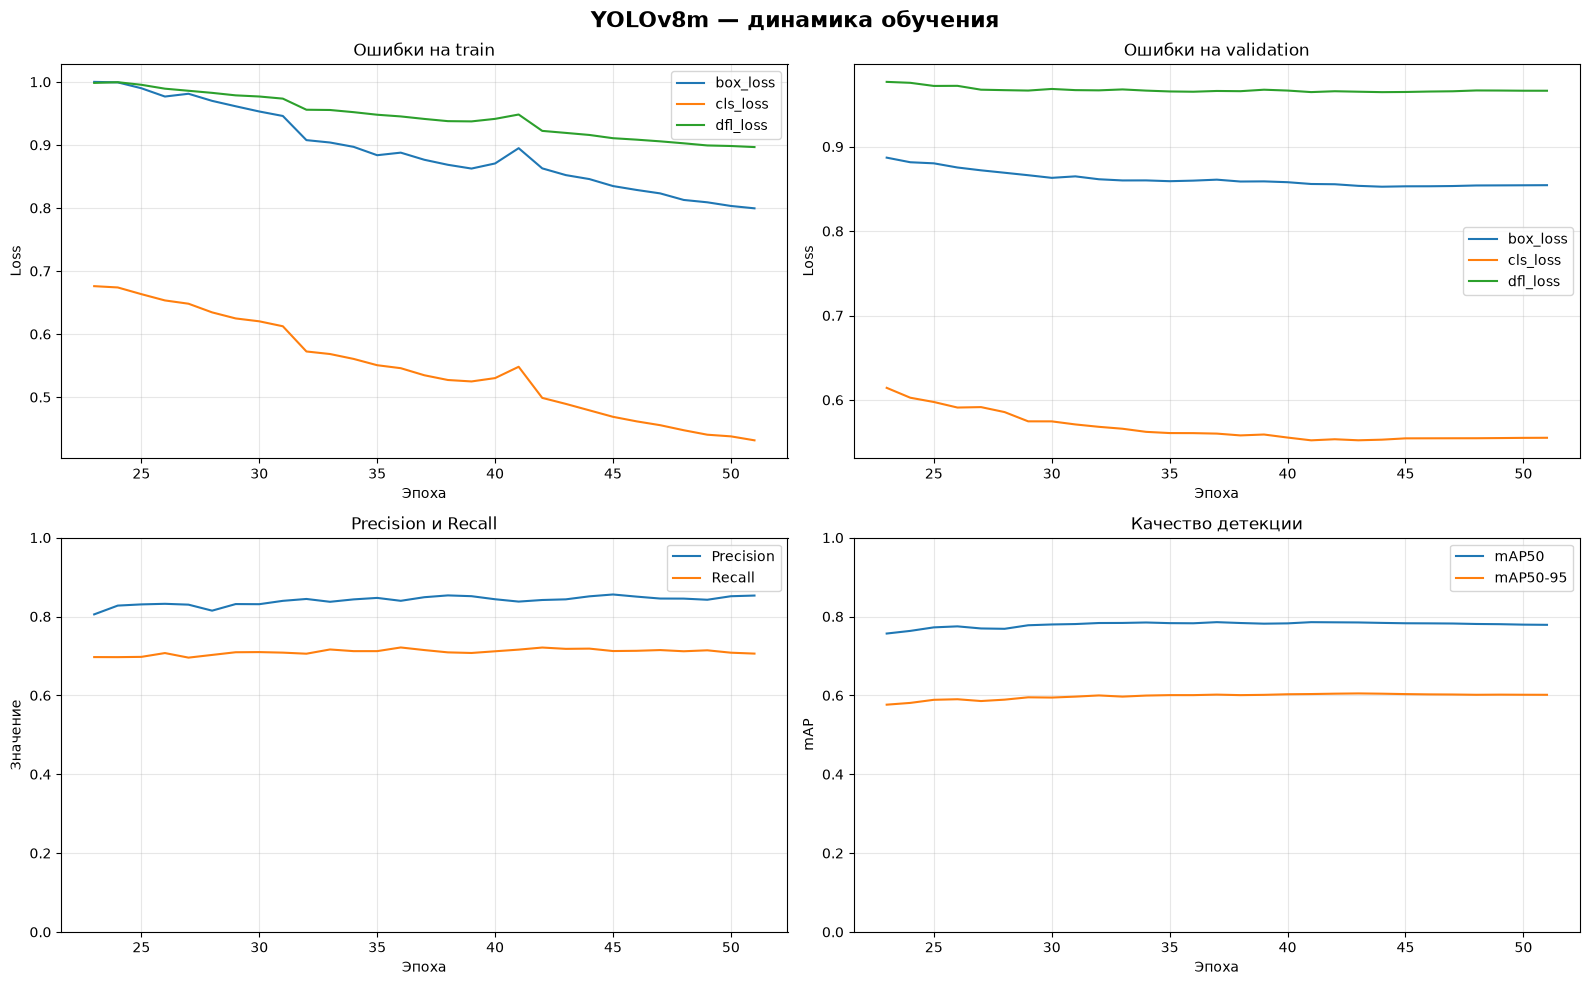

График сохранён: runs\detect\runs_mocs\train\metrics_over_epochs.png


In [2]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

csv_path = Path(r"runs/detect/runs_mocs/train/results.csv")
df = pd.read_csv(csv_path)

# Ultralytics иногда сохраняет пробелы в именах столбцов
df.columns = df.columns.str.strip()

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle("YOLOv8m — динамика обучения", fontsize=16, fontweight="bold")

epoch = df["epoch"] + 1  # отображать эпохи с 1, а не с 0

# Train loss
axes[0, 0].plot(epoch, df["train/box_loss"], label="box_loss")
axes[0, 0].plot(epoch, df["train/cls_loss"], label="cls_loss")
axes[0, 0].plot(epoch, df["train/dfl_loss"], label="dfl_loss")
axes[0, 0].set_title("Ошибки на train")
axes[0, 0].set_xlabel("Эпоха")
axes[0, 0].set_ylabel("Loss")
axes[0, 0].grid(alpha=0.3)
axes[0, 0].legend()

# Validation loss
val_cols = ["val/box_loss", "val/cls_loss", "val/dfl_loss"]
for col in val_cols:
    if col in df.columns:
        axes[0, 1].plot(epoch, df[col], label=col.replace("val/", ""))
axes[0, 1].set_title("Ошибки на validation")
axes[0, 1].set_xlabel("Эпоха")
axes[0, 1].set_ylabel("Loss")
axes[0, 1].grid(alpha=0.3)
axes[0, 1].legend()

# Precision / Recall
axes[1, 0].plot(epoch, df["metrics/precision(B)"], label="Precision")
axes[1, 0].plot(epoch, df["metrics/recall(B)"], label="Recall")
axes[1, 0].set_title("Precision и Recall")
axes[1, 0].set_xlabel("Эпоха")
axes[1, 0].set_ylabel("Значение")
axes[1, 0].set_ylim(0, 1)
axes[1, 0].grid(alpha=0.3)
axes[1, 0].legend()

# mAP
axes[1, 1].plot(epoch, df["metrics/mAP50(B)"], label="mAP50")
axes[1, 1].plot(epoch, df["metrics/mAP50-95(B)"], label="mAP50-95")
axes[1, 1].set_title("Качество детекции")
axes[1, 1].set_xlabel("Эпоха")
axes[1, 1].set_ylabel("mAP")
axes[1, 1].set_ylim(0, 1)
axes[1, 1].grid(alpha=0.3)
axes[1, 1].legend()

plt.tight_layout()
output_path = csv_path.parent / "metrics_over_epochs.png"
plt.savefig(output_path, dpi=180, bbox_inches="tight")
plt.show()

print(f"График сохранён: {output_path}")